<a href="https://colab.research.google.com/github/a00377571/lsm-reconocimiento-mediapipe/blob/main/LSM_ok_dos_manos_MediaPipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Instalación de Dependencias
Comenzamos instalando MediaPipe. También importaremos librerías adicionales que nos serán útiles como OpenCV (`cv2`), Matplotlib y NumPy.

In [1]:
# Reinstalamos de forma limpia para asegurar que los submódulos estén presentes
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 25.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In [2]:
import mediapipe as mp

# Si esta build no expone mp.solutions, lo “reconectamos” desde el submódulo real
if not hasattr(mp, "solutions"):
    from mediapipe.python import solutions as mp_solutions
    mp.solutions = mp_solutions

# Opcional: prueba rápida
print("mp version:", mp.__version__)
print("mp.solutions available:", hasattr(mp, "solutions"))

mp version: 0.10.14
mp.solutions available: True


In [3]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import sys

print("MediaPipe version:", mp.__version__)
print("OpenCV version:", cv2.__version__)

MediaPipe version: 0.10.14
OpenCV version: 4.12.0


### 2. Función Auxiliar para Mostrar Imágenes
En entornos de Notebooks, la mejor manera de visualizar las imágenes procesadas por OpenCV es utilizando `matplotlib.pyplot`. Esta función se encarga de convertir el espacio de color de BGR a RGB y renderizar la imagen de forma correcta.

In [4]:
def mostrar_imagen(imagen, titulo="Imagen", tamaño=(8, 6)):
    """Muestra una imagen de OpenCV usando Matplotlib."""
    plt.figure(figsize=tamaño)
    # OpenCV usa BGR por defecto; lo convertimos a RGB para Matplotlib
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    plt.imshow(imagen_rgb)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

### 3. Práctica 1: Detección de Manos (MediaPipe Hands)
En este ejemplo, descargaremos una imagen de prueba, utilizaremos el modelo `mp.solutions.hands` para procesar la imagen y extraeremos las coordenadas de los puntos clave (nudillos, puntas de los dedos, etc.) para dibujarlos sobre la foto.

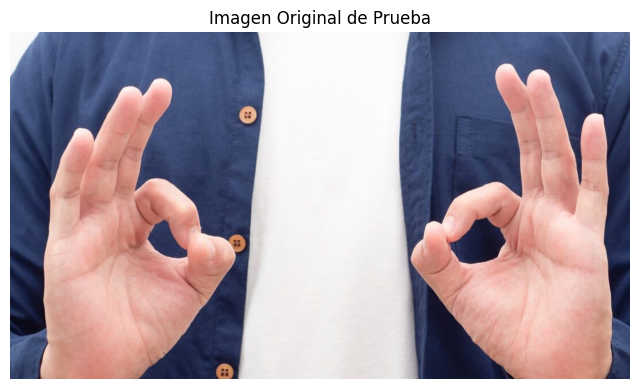

In [5]:
# Descargamos una imagen real de una mano desde un repositorio público
#!wget -q -O left_hand.jpg https://raw.githubusercontent.com/google/mediapipe/master/mediapipe/examples/desktop/hand_tracking/testdata/left_hand.jpg

# Cargamos la imagen
imagen_original = cv2.imread('manos_uno.jpg')

if imagen_original is None:
    print("Error: No se pudo cargar la imagen de prueba.")
else:
    mostrar_imagen(imagen_original, "Imagen Original de Prueba")

In [6]:
import mediapipe as mp
print("mediapipe file:", mp.__file__)
print("version:", getattr(mp, "__version__", "NO __version__"))
print("has solutions?:", hasattr(mp, "solutions"))
print("dir contains solutions?:", "solutions" in dir(mp))

mediapipe file: /usr/local/lib/python3.11/dist-packages/mediapipe/__init__.py
version: 0.10.14
has solutions?: True
dir contains solutions?: True


In [7]:
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


/usr/local/lib/python3.11/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


¡Se detectaron 2 mano(s)!


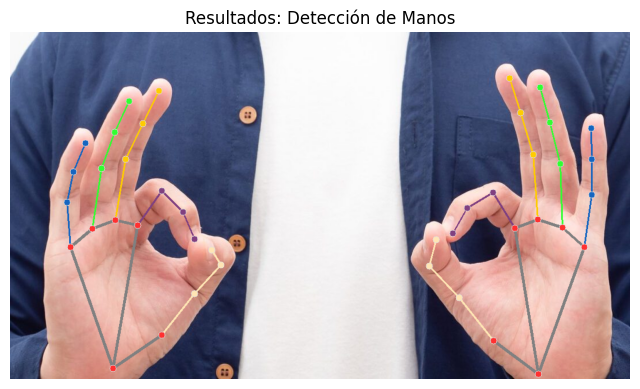

In [8]:
# Importamos directamente los submódulos de soluciones para evitar el AttributeError
from mediapipe.python.solutions import hands as mp_hands
from mediapipe.python.solutions import drawing_utils as mp_drawing
from mediapipe.python.solutions import drawing_styles as mp_drawing_styles

# Copiamos la imagen de base
imagen_dibujo = imagen_original.copy()

# Inicializamos el detector de manos
with mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.5) as hands:

    # Convertimos a RGB para MediaPipe
    imagen_rgb = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)

    # Procesamos la imagen
    resultados = hands.process(imagen_rgb)

    # Dibujamos los puntos si hay detección
    if resultados.multi_hand_landmarks:
        print(f"¡Se detectaron {len(resultados.multi_hand_landmarks)} mano(s)!")
        for hand_landmarks in resultados.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                imagen_dibujo,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style()
            )
        mostrar_imagen(imagen_dibujo, "Resultados: Detección de Manos")
    else:
        print("No se detectaron manos en la imagen.")

Ahora que el modelo está funcionando, veamos qué tipo de datos genera por debajo MediaPipe.

Cuando procesas una imagen con MediaPipe Hands, obtienes un objeto que contiene una lista de puntos clave tridimensionales (X, Y, Z) para cada mano. Cada punto (o landmark) tiene:

x: Coordenada horizontal normalizada (entre 0.0 y 1.0 relativo al ancho de la imagen).
y: Coordenada vertical normalizada (entre 0.0 y 1.0 relativo al alto de la imagen).
z: La profundidad aproximada, teniendo como punto de referencia el plano de la muñeca.
Vamos a extraer y ver los datos numéricos reales de la muñeca (Wrist) y de las puntas de los dedos para entender cómo están representados.

### 4. Analizando los Datos Generados por MediaPipe
Cada mano contiene 21 puntos clave (landmarks). Vamos a imprimir la lista de puntos de la primera mano detectada, mostrando las coordenadas normalizadas y explicando cómo traducirlas a coordenadas reales en píxeles.

In [9]:
if resultados.multi_hand_landmarks:
    # Obtenemos los landmarks de la primera mano detectada
    primera_mano = resultados.multi_hand_landmarks[0]

    # Obtenemos las dimensiones de la imagen original para calcular píxeles reales
    alto, ancho, _ = imagen_original.shape

    print("=== INFORMACIÓN DE LA MANO DETECTADA ===\n")
    print(f"Total de puntos detectados: {len(primera_mano.landmark)}")

    # Mapeo de algunos puntos importantes usando mp_hands.HandLandmark
    puntos_clave = {
        "MUÑECA (WRIST)": mp_hands.HandLandmark.WRIST,
        "PUNTA DEL PULGAR (THUMB_TIP)": mp_hands.HandLandmark.THUMB_TIP,
        "PUNTA DEL ÍNDICE (INDEX_FINGER_TIP)": mp_hands.HandLandmark.INDEX_FINGER_TIP,
        "PUNTA DEL MEDIO (MIDDLE_FINGER_TIP)": mp_hands.HandLandmark.MIDDLE_FINGER_TIP
    }

    for nombre, enum_punto in puntos_clave.items():
        landmark = primera_mano.landmark[enum_punto]
        # Conversión de coordenadas normalizadas a píxeles en la imagen original
        px_x = int(landmark.x * ancho)
        px_y = int(landmark.y * alto)

        print(f"{nombre}:")
        print(f"  -> Coordenadas Normalizadas: (x: {landmark.x:.4f}, y: {landmark.y:.4f}, z: {landmark.z:.4f})")
        print(f"  -> Posición Real en la Imagen: (X: {px_x}px, Y: {px_y}px)\n")
else:
    print("Primero debes ejecutar la celda anterior para que existan 'resultados'.")

=== INFORMACIÓN DE LA MANO DETECTADA ===

Total de puntos detectados: 21
MUÑECA (WRIST):
  -> Coordenadas Normalizadas: (x: 0.1658, y: 0.9691, z: 0.0000)
  -> Posición Real en la Imagen: (X: 179px, Y: 585px)

PUNTA DEL PULGAR (THUMB_TIP):
  -> Coordenadas Normalizadas: (x: 0.3253, y: 0.6276, z: -0.0736)
  -> Posición Real en la Imagen: (X: 351px, Y: 379px)

PUNTA DEL ÍNDICE (INDEX_FINGER_TIP):
  -> Coordenadas Normalizadas: (x: 0.2973, y: 0.5973, z: -0.1110)
  -> Posición Real en la Imagen: (X: 321px, Y: 360px)

PUNTA DEL MEDIO (MIDDLE_FINGER_TIP):
  -> Coordenadas Normalizadas: (x: 0.2404, y: 0.1696, z: -0.0841)
  -> Posición Real en la Imagen: (X: 259px, Y: 102px)



Bien pero ahora quiero exportar estos datos a cvs

¡Excelente idea! Para que puedas trabajar con esta información o usarla para entrenar tus propios modelos, podemos estructurar los 21 puntos clave de la mano en un DataFrame de pandas y exportarlo a un archivo CSV.


Crearemos una tabla con las siguientes columnas:
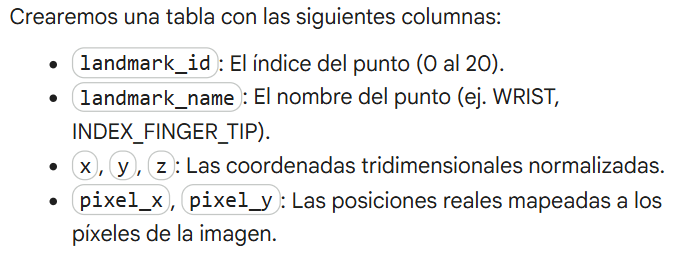

landmark_id: El índice del punto (0 al 20).
landmark_name: El nombre del punto (ej. WRIST, INDEX_FINGER_TIP).
x, y, z: Las coordenadas tridimensionales normalizadas.
pixel_x, pixel_y: Las posiciones reales mapeadas a los píxeles de la imagen.
Aquí tienes el código para generar y descargar ese archivo CSV:

### 5. Exportar los Landmarks de la Mano a un Archivo CSV
Vamos a mapear los 21 puntos clave usando la biblioteca `pandas`, guardarlos en un archivo llamado `landmarks_mano.csv` y mostrar una vista previa de la estructura generada.

In [10]:
import pandas as pd

if resultados.multi_hand_landmarks:
    primera_mano = resultados.multi_hand_landmarks[0]
    alto, ancho, _ = imagen_original.shape

    datos_landmarks = []

    # Recorremos los 21 landmarks oficiales de MediaPipe Hands
    for idx, landmark in enumerate(primera_mano.landmark):
        # Obtener el nombre del landmark desde el enum de MediaPipe
        nombre_landmark = mp_hands.HandLandmark(idx).name

        # Convertir a coordenadas de píxeles
        px_x = int(landmark.x * ancho)
        px_y = int(landmark.y * alto)

        # Guardar en nuestra lista de datos
        datos_landmarks.append({
            "landmark_id": idx,
            "landmark_name": nombre_landmark,
            "x": landmark.x,
            "y": landmark.y,
            "z": landmark.z,
            "pixel_x": px_x,
            "pixel_y": px_y
        })

    # Crear el DataFrame
    df_landmarks = pd.DataFrame(datos_landmarks)

    # Exportar a CSV
    df_landmarks.to_csv('landmarks_mano.csv', index=False)
    print("¡Archivo 'landmarks_mano.csv' guardado correctamente!\n")

    # Mostrar los primeros registros de la tabla
    display(df_landmarks.head(100))
else:
    print("No hay landmarks detectados para exportar.")

¡Archivo 'landmarks_mano.csv' guardado correctamente!



,landmark_id,landmark_name,x,y,z,pixel_x,pixel_y
0,0,WRIST,0.165849,0.969112,1.920393e-07,179,585
1,1,THUMB_CMC,0.244494,0.873299,-1.815076e-02,264,527
2,2,THUMB_MCP,0.297272,0.754570,-3.390893e-02,321,455
3,3,THUMB_IP,0.340051,0.670621,-5.501170e-02,367,405
4,4,THUMB_TIP,0.325316,0.627603,-7.357765e-02,351,379
5,5,INDEX_FINGER_MCP,0.205713,0.556658,6.345386e-03,222,336
6,6,INDEX_FINGER_PIP,0.244566,0.457337,-4.207204e-02,264,276
7,7,INDEX_FINGER_DIP,0.279355,0.519585,-8.748233e-02,301,313
8,8,INDEX_FINGER_TIP,0.297258,0.597273,-1.110276e-01,321,360
9,9,MIDDLE_FINGER_MCP,0.170032,0.542785,-9.285655e-03,183,327


Bien la celda actual modifica para tambien imprimir la lista de puntos de las dos manos detectadas mostrando las coodernadas normalizadas y explicando cómo traducirlas a coordenadas reales
¡Excelente observación! Como la imagen contiene ambas manos y MediaPipe detectó correctamente las 2, lo ideal es adaptar el código para procesar y exportar los datos de ambas en un solo archivo CSV.

### 6. Exportar los Landmarks de Ambas Manos a un Archivo CSV
Modificamos el proceso para iterar sobre todas las manos detectadas (`resultados.multi_hand_landmarks`) en lugar de tomar solo la primera. Añadiremos la columna `hand_index` para identificarlas y añadiremos la columna `etiqueta_lsm`, que es la etiqueta(target) del signo LSM que corresponde a esta imagen.

In [11]:
import pandas as pd

# Definimos la etiqueta del signo LSM que corresponde a esta imagen
etiqueta_lsm = 'OK'  # Puedes cambiar este valor según la seña que estés procesando

if resultados.multi_hand_landmarks:
    alto, ancho, _ = imagen_original.shape
    datos_landmarks = []

    # Iteramos sobre cada una de las manos detectadas
    for mano_idx, hand_landmarks in enumerate(resultados.multi_hand_landmarks):
        print(f"Procesando Mano {mano_idx}...")

        # Recorremos los 21 landmarks oficiales para la mano actual
        for idx, landmark in enumerate(hand_landmarks.landmark):
            nombre_landmark = mp_hands.HandLandmark(idx).name

            # Conversión a píxeles reales
            px_x = int(landmark.x * ancho)
            px_y = int(landmark.y * alto)

            # Guardamos los datos incluyendo el índice de la mano y la etiqueta del signo
            datos_landmarks.append({
                "hand_index": mano_idx,
                "landmark_id": idx,
                "landmark_name": nombre_landmark,
                "x": landmark.x,
                "y": landmark.y,
                "z": landmark.z,
                "pixel_x": px_x,
                "pixel_y": px_y,
                "sign_label": etiqueta_lsm  # Columna identificadora de la seña LSM
            })

    # Crear DataFrame con los datos de todas las manos etiquetadas
    df_todas_manos = pd.DataFrame(datos_landmarks)

    # Exportar a CSV
    df_todas_manos.to_csv('landmarks_todas_manos.csv', index=False)
    print("\n¡Archivo 'landmarks_todas_manos.csv' actualizado y guardado con éxito!")
    print(f"Se exportaron en total {len(df_todas_manos)} registros con la etiqueta '{etiqueta_lsm}'.\n")

    # Mostrar una vista previa (primeros 3 registros de cada mano para verificar la nueva columna)
    display(df_todas_manos.groupby('hand_index').head(3))
else:
    print("No se detectaron manos para exportar.")

Procesando Mano 0...
Procesando Mano 1...

¡Archivo 'landmarks_todas_manos.csv' actualizado y guardado con éxito!
Se exportaron en total 42 registros con la etiqueta 'OK'.



,hand_index,landmark_id,landmark_name,x,y,z,pixel_x,pixel_y,sign_label
0,0,0,WRIST,0.165849,0.969112,1.920393e-07,179,585,OK
1,0,1,THUMB_CMC,0.244494,0.873299,-1.815076e-02,264,527,OK
2,0,2,THUMB_MCP,0.297272,0.754570,-3.390893e-02,321,455,OK
21,1,0,WRIST,0.852308,0.985941,-1.708913e-07,920,595,OK
22,1,1,THUMB_CMC,0.780198,0.890370,-1.758861e-02,842,537,OK
23,1,2,THUMB_MCP,0.724118,0.765001,-3.775599e-02,782,462,OK


### 7. Normalización de Datos para Machine Learning
Para entrenar un modelo que reconozca señas LSM de manera confiable, es fundamental que las coordenadas sean **invariantes a la traslación y a la escala**:

1. **Invarianza a la Traslación (Centrado):** Restamos las coordenadas de la muñeca ($X_{wrist}, Y_{wrist}, Z_{wrist}$) a todos los demás puntos. Esto hace que la muñeca sea siempre el origen $(0,0,0)$, eliminando el efecto de la posición de la mano en la pantalla.
2. **Invarianza a la Escala (Escalado/Normalización de Tamaño):** Calculamos la distancia máxima desde la muñeca a cualquier otro landmark (o una distancia conocida como la distancia de la muñeca al nudillo base) y dividimos todos los puntos entre este factor. Así, no importa si la mano está cerca o lejos de la cámara.

Vamos a aplicar esta técnica de normalización sobre el DataFrame que acabamos de exportar.

In [12]:
import numpy as np

def normalizar_mano(df_grupo):
    """Normaliza las coordenadas de una sola mano para que la muñeca sea el (0,0,0)
    y los puntos se escalen de manera proporcional.
    """
    # 1. Obtener coordenadas de la muñeca (landmark_id == 0)
    wrist = df_grupo[df_grupo['landmark_id'] == 0]
    if wrist.empty:
        return df_grupo

    wrist_x = wrist['x'].values[0]
    wrist_y = wrist['y'].values[0]
    wrist_z = wrist['z'].values[0]

    # 2. Restar las coordenadas de la muñeca (Centrado)
    df_grupo['x_norm'] = df_grupo['x'] - wrist_x
    df_grupo['y_norm'] = df_grupo['y'] - wrist_y
    df_grupo['z_norm'] = df_grupo['z'] - wrist_z

    # 3. Calcular la distancia máxima de los puntos al origen (Muñeca) para escalar
    distancias = np.sqrt(df_grupo['x_norm']**2 + df_grupo['y_norm']**2 + df_grupo['z_norm']**2)
    max_distancia = distancias.max()

    # Evitar división por cero si por alguna razón la distancia máxima es 0
    if max_distancia > 0:
        df_grupo['x_norm'] = df_grupo['x_norm'] / max_distancia
        df_grupo['y_norm'] = df_grupo['y_norm'] / max_distancia
        df_grupo['z_norm'] = df_grupo['z_norm'] / max_distancia

    return df_grupo

# Aplicamos la normalización agrupando por cada mano (hand_index)
df_normalizado = df_todas_manos.groupby('hand_index', group_keys=False).apply(normalizar_mano)

# Guardamos los datos normalizados preparados para entrenamiento
df_normalizado.to_csv('landmarks_normalizados_lsm.csv', index=False)
print("¡Datos normalizados y exportados con éxito a 'landmarks_normalizados_lsm.csv'!")

# Mostramos una vista previa de los puntos clave transformados (notarás que para la muñeca x_norm, y_norm y z_norm serán 0.0)
display(df_normalizado[['hand_index', 'landmark_name', 'x_norm', 'y_norm', 'z_norm', 'sign_label']].head(5))

¡Datos normalizados y exportados con éxito a 'landmarks_normalizados_lsm.csv'!


/tmp/ipython-input-12-1543218915.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_normalizado = df_todas_manos.groupby('hand_index', group_keys=False).apply(normalizar_mano)


,hand_index,landmark_name,x_norm,y_norm,z_norm,sign_label
0,0,WRIST,0.000000,0.000000,0.000000,OK
1,0,THUMB_CMC,0.097404,-0.118668,-0.022480,OK
2,0,THUMB_MCP,0.162771,-0.265716,-0.041997,OK
3,0,THUMB_IP,0.215754,-0.369689,-0.068134,OK
4,0,THUMB_TIP,0.197504,-0.422968,-0.091128,OK


Explica cómo usar `df_todas_manos` para entrenar un modelo de clasificación
Para entrenar un modelo de clasificación con df_todas_manos (o df_normalizado), el paso clave es redimensionar (pivotar) los datos.

Actualmente, cada mano tiene 21 filas (un registro por landmark). Para entrenar un clasificador (como Random Forest o una Red Neuronal), necesitamos que cada mano sea una sola fila en nuestro dataset, donde las columnas sean todas las coordenadas unidas (21 landmarks $\times$$\times$ 3 coordenadas = 63 características por muestra).

He creado una explicación paso a paso y el código para transformar tus datos y simular el entrenamiento de un clasificador.

### 8. Cómo preparar y usar los datos para entrenar un modelo de Clasificación

Para pasar de un conjunto de landmarks secuenciales a un modelo de Machine Learning, seguimos estos pasos:

1. **Aplanamiento (Flattening):** Convertimos las 21 coordenadas $(x, y, z)$ de cada mano en un único vector de 63 características ($21 \times 3 = 63$).
2. **Definición de X e y:**
   - **$X$ (Características):** El vector plano de 63 coordenadas normalizadas.
   - **$y$ (Etiqueta):** El signo correspondiente de la columna `sign_label`.
3. **Entrenamiento:** Usamos un clasificador robusto como **Random Forest** o un **SVM** para aprender a mapear esas 63 entradas hacia la etiqueta correcta.

In [13]:
# 1. Pivotamos el DataFrame para que cada mano ('hand_index') sea un único registro
# Usamos las coordenadas ya normalizadas para asegurar invarianza de escala y posición
df_features = df_normalizado.pivot(
    index=['hand_index', 'sign_label'],
    columns='landmark_id',
    values=['x_norm', 'y_norm', 'z_norm']
)

# Aplanamos los niveles de las columnas para tener nombres sencillos como 'x_norm_0', 'y_norm_0', etc.
df_features.columns = [f"{coord}_{idx}" for coord, idx in df_features.columns]
df_features = df_features.reset_index()

print("Estructura del dataset listo para Machine Learning:")
print(f"Filas (ejemplos de manos): {df_features.shape[0]}")
print(f"Columnas (características + metadatos): {df_features.shape[1]}\n")

# Mostramos las primeras columnas y el resultado final
display(df_features.head())

Estructura del dataset listo para Machine Learning:
Filas (ejemplos de manos): 2
Columnas (características + metadatos): 65



,hand_index,sign_label,x_norm_0,x_norm_1,x_norm_2,x_norm_3,x_norm_4,x_norm_5,x_norm_6,x_norm_7,...,z_norm_11,z_norm_12,z_norm_13,z_norm_14,z_norm_15,z_norm_16,z_norm_17,z_norm_18,z_norm_19,z_norm_20
0,0,OK,0.0,0.097404,0.162771,0.215754,0.197504,0.049373,0.097493,0.140581,...,-0.077577,-0.104187,-0.041705,-0.070867,-0.096296,-0.113637,-0.076379,-0.092624,-0.096293,-0.100413
1,1,OK,0.0,-0.084163,-0.149616,-0.205761,-0.192050,-0.044006,-0.084915,-0.133477,...,-0.066990,-0.080011,-0.036258,-0.064964,-0.076419,-0.079438,-0.068599,-0.081902,-0.079354,-0.074345


### Ejemplo de Entrenamiento con Scikit-Learn

Aquí tienes una simulación de cómo se dividirían los datos y se entrenaría un modelo clasificador de **Random Forest** una vez que tengas múltiples imágenes recopiladas en tu dataset.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Separamos las características (X) de la etiqueta objetivo (y)
# Excluimos las columnas de metadatos como 'hand_index' y la propia etiqueta 'sign_label'
columnas_caracteristicas = [col for col in df_features.columns if col not in ['hand_index', 'sign_label']]

X = df_features[columnas_caracteristicas].values
y = df_features['sign_label'].values

print(f"Forma de X (Entradas del modelo): {X.shape}")
print(f"Forma de y (Salidas/Etiquetas): {y.shape}")

# NOTA: Como en este ejemplo interactivo solo tenemos una imagen (2 manos de la misma seña 'OK'),
# usaremos los datos disponibles para ilustrar la inicialización y sintaxis del modelo.

# Inicializamos el clasificador
modelo_lsm = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenamos el modelo
modelo_lsm.fit(X, y)
print("\n¡Modelo de clasificación inicializado y entrenado con éxito sobre los datos de prueba!")

Forma de X (Entradas del modelo): (2, 63)
Forma de y (Salidas/Etiquetas): (2,)

¡Modelo de clasificación inicializado y entrenado con éxito sobre los datos de prueba!


### 9. Procesamiento por Lotes (Batch Processing) de Múltiples Imágenes

A continuación, se presentan los dos métodos para cargar imágenes de forma masiva y agregarlas a tu dataset de entrenamiento.

#### Opción A: Descargar desde un Repositorio Web (URLs)
Si tienes una lista de enlaces directos a las imágenes en un servidor o repositorio de GitHub, puedes descargarlas y procesarlas directamente.

In [15]:
import urllib.request
import os

# Lista de ejemplo con URLs de imágenes y sus respectivas etiquetas LSM
imagenes_web = [
    {
        "url": "https://raw.githubusercontent.com/google/mediapipe/master/mediapipe/examples/desktop/hand_tracking/testdata/left_hand.jpg",
        "label": "Mano_Izquierda_Prueba"
    }
    # Puedes añadir aquí más URLs y etiquetas
]

os.makedirs('/content/imagenes_descargadas', exist_ok=True)

for idx, item in enumerate(imagenes_web):
    ruta_destino = f"/content/imagenes_descargadas/imagen_{idx}.jpg"
    try:
        urllib.request.urlretrieve(item['url'], ruta_destino)
        print(f"Descargada: {ruta_destino} (Etiqueta: {item['label']})")
    except Exception as e:
        print(f"Error al descargar {item['url']}: {e}")

Error al descargar https://raw.githubusercontent.com/google/mediapipe/master/mediapipe/examples/desktop/hand_tracking/testdata/left_hand.jpg: HTTP Error 404: Not Found


#### Opción B: Leer desde Google Drive (Recomendado para Datasets Propios)
Este bloque te permite conectar tu Google Drive. Al ejecutarlo, Colab te pedirá autorización de acceso.

In [16]:
# Descomenta estas líneas si deseas conectar tu Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Una vez montado, puedes definir la ruta de tu carpeta de señas:
# ruta_dataset = '/content/drive/MyDrive/LSM_Dataset/'

#### Pipeline de Procesamiento Masivo y Extracción Automatizada
El siguiente script recorre una carpeta local de imágenes (por ejemplo, la carpeta de descargas de la Opción A o una carpeta de tu Drive), extrae los landmarks de cada mano detectada, los normaliza automáticamente y los concatena en un único DataFrame listo para entrenar el modelo.

In [17]:
import glob

def procesar_lote_imagenes(carpeta_origen, etiqueta_defecto='Desconocido'):
    """Busca imágenes en la carpeta, extrae landmarks, los normaliza y los consolida."""
    datos_totales = []
    formatos = ['*.jpg', '*.jpeg', '*.png']
    archivos_imagen = []

    for ext in formatos:
        archivos_imagen.extend(glob.glob(os.path.join(carpeta_origen, ext)))

    if not archivos_imagen:
        print("No se encontraron imágenes en la carpeta especificada.")
        return pd.DataFrame()

    # Re-inicializamos el detector de MediaPipe
    with mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.5) as hands:
        for img_path in archivos_imagen:
            nombre_archivo = os.path.basename(img_path)
            img = cv2.imread(img_path)
            if img is None:
                continue

            alto, ancho, _ = img.shape
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            resultados_batch = hands.process(img_rgb)

            if resultados_batch.multi_hand_landmarks:
                for mano_idx, hand_landmarks in enumerate(resultados_batch.multi_hand_landmarks):
                    for idx, landmark in enumerate(hand_landmarks.landmark):
                        datos_totales.append({
                            "image_name": nombre_archivo,
                            "hand_index": mano_idx,
                            "landmark_id": idx,
                            "landmark_name": mp_hands.HandLandmark(idx).name,
                            "x": landmark.x,
                            "y": landmark.y,
                            "z": landmark.z,
                            "sign_label": etiqueta_defecto  # Aquí puedes mapear dinámicamente según el nombre de la carpeta
                        })

    df_batch = pd.DataFrame(datos_totales)

    # Aplicamos la normalización agrupando por imagen y por mano
    if not df_batch.empty:
        df_batch = df_batch.groupby(['image_name', 'hand_index'], group_keys=False).apply(normalizar_mano)
        print(f"Procesadas con éxito {len(archivos_imagen)} imágenes.")
    return df_batch

# Ejecución de prueba con la carpeta de imágenes web que descargamos
df_lote_procesado = procesar_lote_imagenes('/content/imagenes_descargadas', etiqueta_defecto='Seña_Ejemplo')
if not df_lote_procesado.empty:
    display(df_lote_procesado.head(5))


No se encontraron imágenes en la carpeta especificada.


## **Practica 2. Extracción de landmarks desde un video con MediaPipe**


In [22]:
import os
import cv2
import numpy as np
import mediapipe as mp

VIDEO_PATH = r"/content/sample_data/videos/hola_uno.mp4"
OUT_PATH   = r"output/lsm_hola_01_hands.npz"

MAX_HANDS = 2
DRAW = False   # Ponemos False en Colab para evitar errores con cv2.imshow
SKIP = 1      # procesa cada frame; usa 2 o 3 si quieres acelerar

def main():
    os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)

    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        raise RuntimeError(f"No se pudo abrir el video: {VIDEO_PATH}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 0.0

    mp_hands = mp.solutions.hands
    mp_draw = mp.solutions.drawing_utils

    seq = []  # lista de (2, 21, 3) por frame

    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=MAX_HANDS,
        model_complexity=1,
        min_detection_confidence=0.6,
        min_tracking_confidence=0.6
    ) as hands:

        t = 0
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            # Saltar frames si se desea
            if (t % SKIP) != 0:
                t += 1
                continue
            t += 1

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = hands.process(rgb)

            # (Left, Right) -> 0,1. NaN si no está.
            arr = np.full((2, 21, 3), np.nan, dtype=np.float32)

            if res.multi_hand_landmarks and res.multi_handedness:
                for hand_lms, handedness in zip(res.multi_hand_landmarks, res.multi_handedness):
                    label = handedness.classification[0].label  # "Left" o "Right"
                    hand_index = 0 if label == "Left" else 1

                    for j, lm in enumerate(hand_lms.landmark):
                        arr[hand_index, j, 0] = lm.x
                        arr[hand_index, j, 1] = lm.y
                        arr[hand_index, j, 2] = lm.z

                    if DRAW:
                        mp_draw.draw_landmarks(frame, hand_lms, mp_hands.HAND_CONNECTIONS)

            seq.append(arr)

            if DRAW:
                cv2.imshow("Extract Hands (ESC para salir)", frame)
                if cv2.waitKey(1) & 0xFF == 27:
                    break

    cap.release()
    if DRAW:
        cv2.destroyAllWindows()

    seq = np.stack(seq, axis=0)  # (T, 2, 21, 3)

    np.savez_compressed(
        OUT_PATH,
        hands=seq,
        fps=np.array([fps], dtype=np.float32)
    )

    print("Listo.")
    print("Salida:", OUT_PATH)
    print("hands shape:", seq.shape, "  (T, 2, 21, 3)")
    print("fps:", fps)

if __name__ == "__main__":
    main()

/usr/local/lib/python3.11/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Listo.
Salida: output/lsm_hola_01_hands.npz
hands shape: (95, 2, 21, 3)   (T, 2, 21, 3)
fps: 30.009898001446093


Confirmación de éxito:
Como puedes ver en la salida estándar (standard_output), el script finalizó correctamente:

Archivo guardado: Se generó el archivo en output/lsm_hola_01_hands.npz.
Frames procesados: Se extrajeron las coordenadas de las manos de 95 frames del video.
Dimensiones: La estructura obtenida es de (95, 2, 21, 3), correspondiente a: (Número de Frames, 2 Manos, 21 Puntos clave, Coordenadas X/Y/Z).

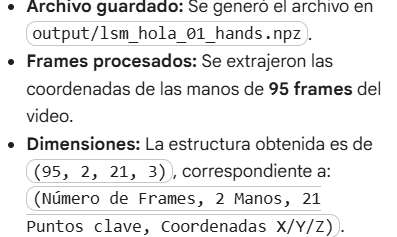

Visualiza los landmarks extraídos en el archivo 'output/lsm_hola_01_hands.npz'
He creado una celda de código para visualizar los landmarks que acabas de extraer en el archivo .npz.

Este script cargará el archivo /content/output/lsm_hola_01_hands.npz, extraerá las coordenadas de las manos de un frame específico (por ejemplo, el frame del medio del video) y las graficará en un espacio tridimensional (3D) usando matplotlib. Así podrás verificar visualmente la estructura tridimensional de los puntos detectados para ambas manos.

Archivo cargado correctamente: output/lsm_hola_01_hands.npz
Total de frames (T): 95
FPS del video original: 30.01


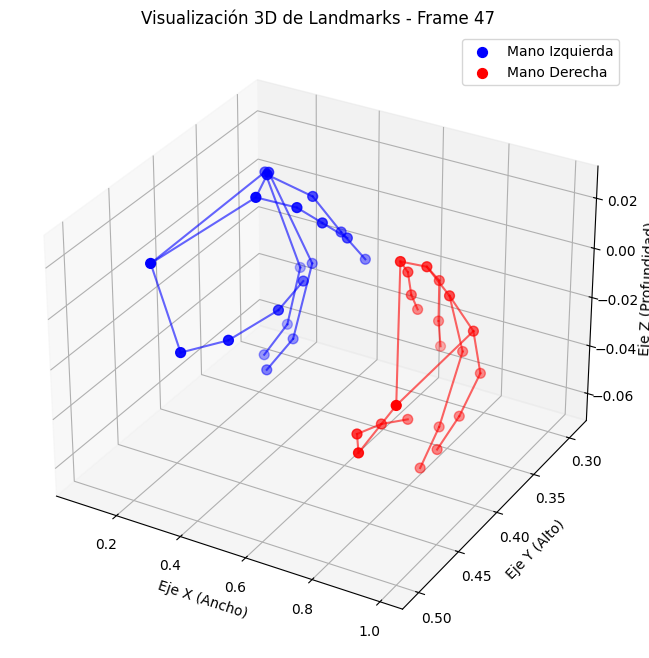

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Cargar el archivo guardado
npz_path = "output/lsm_hola_01_hands.npz"
data = np.load(npz_path)
hands_sequence = data['hands']  # Forma: (T, 2, 21, 3)
fps = data['fps'][0]

print(f"Archivo cargado correctamente: {npz_path}")
print(f"Total de frames (T): {hands_sequence.shape[0]}")
print(f"FPS del video original: {fps:.2f}")

# 2. Seleccionar un frame representativo (por ejemplo, la mitad del video) para visualizar
frame_idx = hands_sequence.shape[0] // 2
frame_data = hands_sequence[frame_idx]  # Forma: (2, 21, 3)

# Conexiones oficiales de los dedos en MediaPipe para dibujar las líneas de la mano
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),           # Pulgar
    (0, 5), (5, 6), (6, 7), (7, 8),           # Índice
    (5, 9), (9, 10), (10, 11), (11, 12),      # Medio
    (9, 13), (13, 14), (14, 15), (15, 16),    # Anular
    (13, 17), (0, 17), (17, 18), (18, 19), (19, 20) # Meñique
]

# 3. Configurar gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colores = {0: 'blue', 1: 'red'}  # Azul para mano Izquierda (index 0), Rojo para Derecha (index 1)
etiquetas = {0: 'Mano Izquierda', 1: 'Mano Derecha'}

# Graficar cada mano si contiene datos (no son NaN)
for hand_idx in [0, 1]:
    landmarks = frame_data[hand_idx]  # (21, 3)

    # Si todos los puntos son NaN, significa que esa mano no se detectó en ese frame
    if np.isnan(landmarks).all():
        print(f"En el frame {frame_idx}, la {etiquetas[hand_idx]} no fue detectada.")
        continue

    # Dibujar los puntos (landmarks)
    ax.scatter(landmarks[:, 0], landmarks[:, 1], landmarks[:, 2],
               color=colores[hand_idx], s=50, label=etiquetas[hand_idx])

    # Dibujar las líneas de conexión entre puntos
    for connection in HAND_CONNECTIONS:
        p1, p2 = connection
        x_coords = [landmarks[p1, 0], landmarks[p2, 0]]
        y_coords = [landmarks[p1, 1], landmarks[p2, 1]]
        z_coords = [landmarks[p1, 2], landmarks[p2, 2]]
        ax.plot(x_coords, y_coords, z_coords, color=colores[hand_idx], alpha=0.6)

# Ajustar vista y etiquetas de los ejes
ax.set_title(f"Visualización 3D de Landmarks - Frame {frame_idx}")
ax.set_xlabel("Eje X (Ancho)")
ax.set_ylabel("Eje Y (Alto)")
ax.set_zlabel("Eje Z (Profundidad)")

# Invertir eje Y para que coincida con la orientación de las imágenes (origen arriba-izquierda)
ax.invert_yaxis()

ax.legend()
plt.show()

Crea un video o animación con la secuencia completa de landmarks
¡Excelente idea! Para ver la secuencia completa de landmarks en movimiento, he creado un bloque de código que genera una animación en 3D utilizando matplotlib.animation.

Este código tomará cada uno de los 95 frames del archivo output/lsm_hola_01_hands.npz, reconstruirá las conexiones de las manos y guardará la animación como un video HTML5 directamente visible en tu libreta de Google Colab.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Cargar la secuencia completa de landmarks
npz_path = "output/lsm_hola_01_hands.npz"
data = np.load(npz_path)
hands_sequence = data['hands']  # Forma: (T, 2, 21, 3)

# Definición de conexiones para dibujar las líneas de los dedos
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),           # Pulgar
    (0, 5), (5, 6), (6, 7), (7, 8),           # Índice
    (5, 9), (9, 10), (10, 11), (11, 12),      # Medio
    (9, 13), (13, 14), (14, 15), (15, 16),    # Anular
    (13, 17), (0, 17), (17, 18), (18, 19), (19, 20) # Meñique
]

# 2. Configurar la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Encontrar los límites máximos y mínimos omitiendo los NaN
valid_mask = ~np.isnan(hands_sequence)
if np.any(valid_mask):
    x_coords = hands_sequence[..., 0][valid_mask[..., 0]]
    y_coords = hands_sequence[..., 1][valid_mask[..., 1]]
    z_coords = hands_sequence[..., 2][valid_mask[..., 2]]
    min_x, max_x = np.min(x_coords), np.max(x_coords)
    min_y, max_y = np.min(y_coords), np.max(y_coords)
    min_z, max_z = np.min(z_coords), np.max(z_coords)
else:
    min_x, max_x = 0, 1
    min_y, max_y = 0, 1
    min_z, max_z = 0, 1

# Listas para almacenar los objetos de dibujo que actualizaremos en cada frame
scatter_plots = []
line_plots = []

# Inicializar los plots (Mano Izquierda = 0, Mano Derecha = 1)
colores = {0: 'blue', 1: 'red'}
etiquetas = {0: 'Mano Izquierda', 1: 'Mano Derecha'}

# Creación de marcadores iniciales
for h in [0, 1]:
    scatter = ax.scatter([], [], [], color=colores[h], s=40, label=etiquetas[h])
    scatter_plots.append(scatter)

    lines = [ax.plot([], [], [], color=colores[h], alpha=0.6)[0] for _ in HAND_CONNECTIONS]
    line_plots.append(lines)

# Función para inicializar la escena 3D
def init():
    ax.set_xlim(min_x - 0.1, max_x + 0.1)
    ax.set_ylim(min_y - 0.1, max_y + 0.1)
    ax.set_zlim(min_z - 0.1, max_z + 0.1)
    ax.set_xlabel("Eje X (Ancho)")
    ax.set_ylabel("Eje Y (Alto)")
    ax.set_zlabel("Eje Z (Profundidad)")
    ax.invert_yaxis()  # Invertir eje Y para respetar perspectiva original
    ax.legend()
    return []

# Función de actualización para cada frame de la animación
def update(frame_idx):
    frame_data = hands_sequence[frame_idx]
    artists = []

    ax.set_title(f"Animación 3D Landmarks - Frame {frame_idx + 1}/{len(hands_sequence)}")

    for h in [0, 1]:
        landmarks = frame_data[h]  # (21, 3)

        if np.isnan(landmarks).all():
            # Si no hay detección, ocultar puntos y líneas
            scatter_plots[h]._offsets3d = ([], [], [])
            for line in line_plots[h]:
                line.set_data([], [])
                line.set_3d_properties([])
        else:
            # Actualizar puntos 3D
            scatter_plots[h]._offsets3d = (landmarks[:, 0], landmarks[:, 1], landmarks[:, 2])

            # Actualizar líneas de conexión
            for idx, connection in enumerate(HAND_CONNECTIONS):
                p1, p2 = connection
                x_line = [landmarks[p1, 0], landmarks[p2, 0]]
                y_line = [landmarks[p1, 1], landmarks[p2, 1]]
                z_line = [landmarks[p1, 2], landmarks[p2, 2]]

                line_plots[h][idx].set_data(x_line, y_line)
                line_plots[h][idx].set_3d_properties(z_line)
                artists.append(line_plots[h][idx])

        artists.append(scatter_plots[h])

    return artists

# 3. Crear la animación
anim = FuncAnimation(
    fig, update, frames=len(hands_sequence), init_func=init, interval=50, blit=False
)

# Renderizar directamente en Colab como video HTML5
plt.close(fig)  # Cerrar la figura estática de fondo para evitar duplicados
HTML(anim.to_html5_video())

Grafica la trayectoria de la muñeca a lo largo de los frame extraidos.

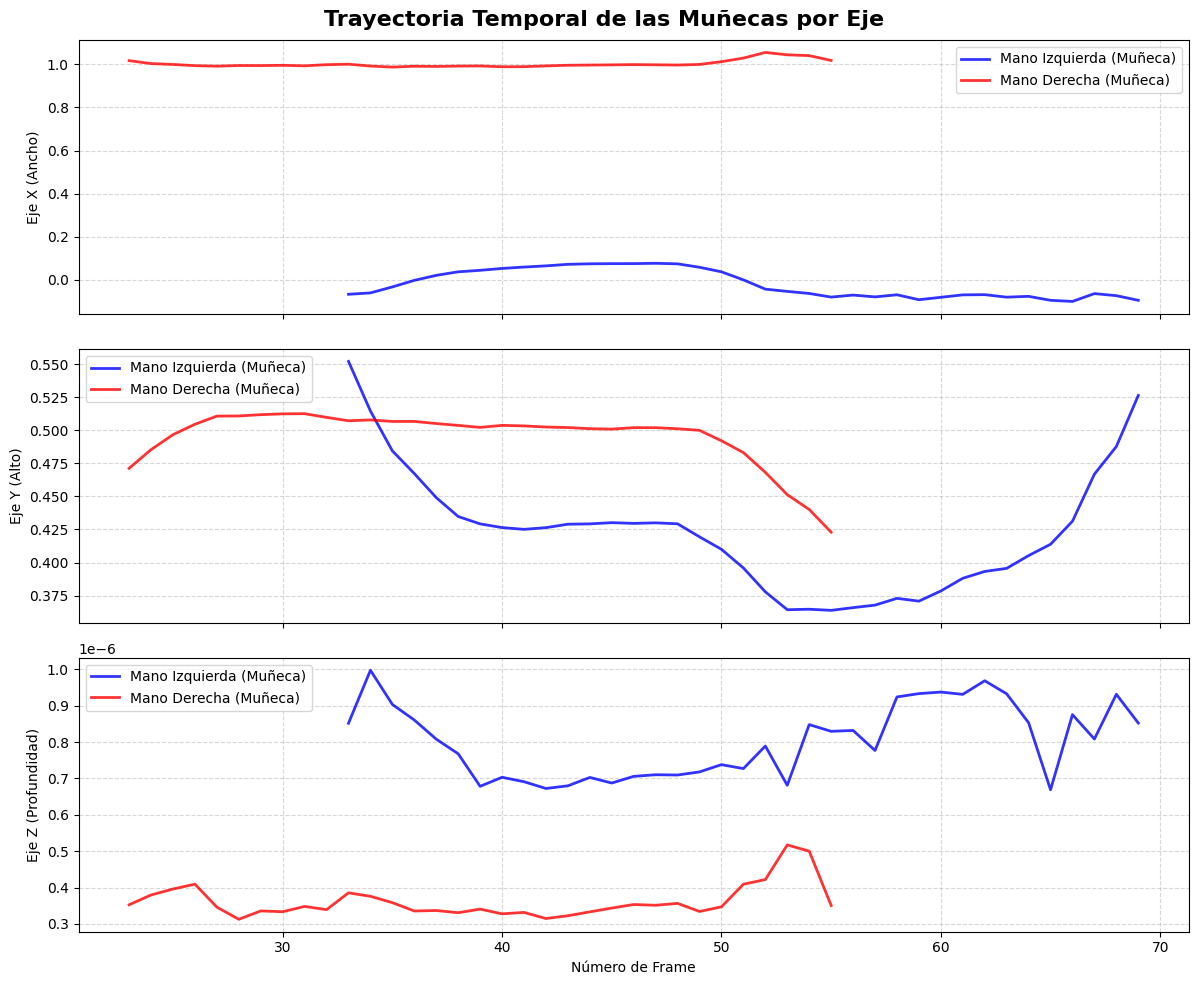

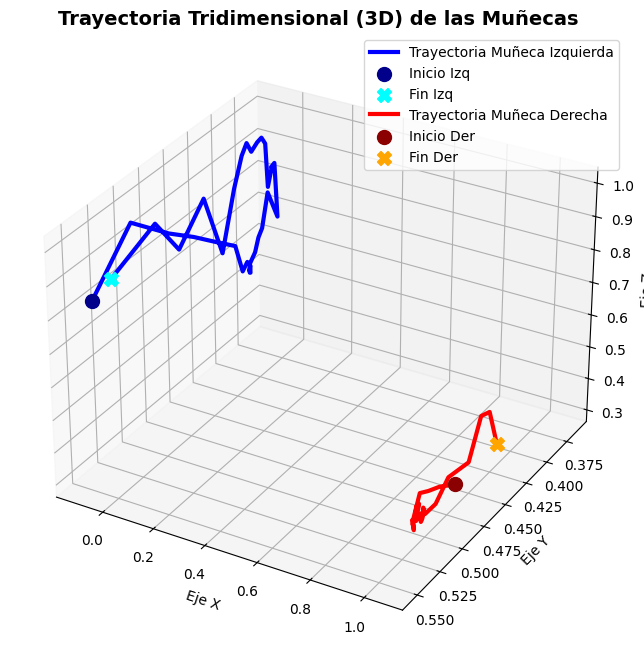

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar la secuencia completa de landmarks
npz_path = "output/lsm_hola_01_hands.npz"
data = np.load(npz_path)
hands_sequence = data['hands']  # Forma: (T, 2, 21, 3)

# El landmark de la muñeca (Wrist) es el índice 0
wrist_idx = 0

# Extraer las coordenadas (X, Y, Z) de la muñeca a lo largo del tiempo
# hands_sequence[:, 0, wrist_idx, :] -> Muñeca Mano Izquierda
# hands_sequence[:, 1, wrist_idx, :] -> Muñeca Mano Derecha
wrist_left = hands_sequence[:, 0, wrist_idx, :]   # Forma: (T, 3)
wrist_right = hands_sequence[:, 1, wrist_idx, :]  # Forma: (T, 3)

frames = np.arange(len(hands_sequence))

# 2. Configurar la figura para trayectorias temporales (2D por componente)
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

componentes = ['Eje X (Ancho)', 'Eje Y (Alto)', 'Eje Z (Profundidad)']
colores = ['blue', 'red']

for i in range(3):
    # Graficar mano izquierda (index 0)
    axs[i].plot(frames, wrist_left[:, i], label='Mano Izquierda (Muñeca)', color='blue', alpha=0.8, linewidth=2)
    # Graficar mano derecha (index 1)
    axs[i].plot(frames, wrist_right[:, i], label='Mano Derecha (Muñeca)', color='red', alpha=0.8, linewidth=2)

    axs[i].set_ylabel(componentes[i])
    axs[i].grid(True, linestyle='--', alpha=0.5)
    axs[i].legend()

axs[2].set_xlabel('Número de Frame')
plt.suptitle('Trayectoria Temporal de las Muñecas por Eje', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Configurar gráfico 3D de las trayectorias espaciales
fig_3d = plt.figure(figsize=(10, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# Graficar trayectoria 3D de la mano izquierda (omitiendo los NaNs para trazar la línea continua)
mask_left = ~np.isnan(wrist_left[:, 0])
if np.any(mask_left):
    ax_3d.plot(wrist_left[mask_left, 0], wrist_left[mask_left, 1], wrist_left[mask_left, 2],
               color='blue', label='Trayectoria Muñeca Izquierda', linewidth=3)
    ax_3d.scatter(wrist_left[mask_left, 0][0], wrist_left[mask_left, 1][0], wrist_left[mask_left, 2][0],
                  color='darkblue', marker='o', s=100, label='Inicio Izq')
    ax_3d.scatter(wrist_left[mask_left, 0][-1], wrist_left[mask_left, 1][-1], wrist_left[mask_left, 2][-1],
                  color='cyan', marker='X', s=100, label='Fin Izq')

# Graficar trayectoria 3D de la mano derecha (omitiendo los NaNs)
mask_right = ~np.isnan(wrist_right[:, 0])
if np.any(mask_right):
    ax_3d.plot(wrist_right[mask_right, 0], wrist_right[mask_right, 1], wrist_right[mask_right, 2],
               color='red', label='Trayectoria Muñeca Derecha', linewidth=3)
    ax_3d.scatter(wrist_right[mask_right, 0][0], wrist_right[mask_right, 1][0], wrist_right[mask_right, 2][0],
                  color='darkred', marker='o', s=100, label='Inicio Der')
    ax_3d.scatter(wrist_right[mask_right, 0][-1], wrist_right[mask_right, 1][-1], wrist_right[mask_right, 2][-1],
                  color='orange', marker='X', s=100, label='Fin Der')

ax_3d.set_title('Trayectoria Tridimensional (3D) de las Muñecas', fontsize=14, fontweight='bold')
ax_3d.set_xlabel('Eje X')
ax_3d.set_ylabel('Eje Y')
ax_3d.set_zlabel('Eje Z')
ax_3d.invert_yaxis() # Mantener consistencia con el espacio de la cámara
ax_3d.legend()
plt.show()

## **Script 2 — Análisis rápido: % de frames con mano detectada + trayectoria de muñeca**

Frames totales: 95
FPS: 30.009897232055664
Left detect %: 38.94736842105263
Right detect %: 34.73684210526316


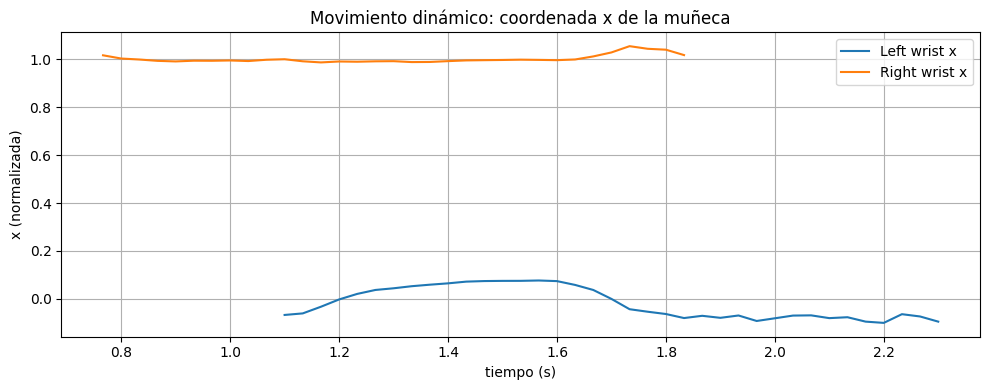

In [28]:
import numpy as np
import matplotlib.pyplot as plt

NPZ_PATH = r"output/lsm_hola_01_hands.npz"

def main():
    data = np.load(NPZ_PATH)
    hands = data["hands"]  # (T, 2, 21, 3)
    fps = float(data["fps"][0]) if "fps" in data else 0.0
    T = hands.shape[0]

    # Wrist = landmark 0
    left_wrist  = hands[:, 0, 0, :2]  # (T, 2) -> x,y
    right_wrist = hands[:, 1, 0, :2]

    left_detect  = ~np.isnan(left_wrist[:, 0])
    right_detect = ~np.isnan(right_wrist[:, 0])

    print("Frames totales:", T)
    print("FPS:", fps)
    print("Left detect %:", 100 * left_detect.mean())
    print("Right detect %:", 100 * right_detect.mean())

    # Tiempo (si fps disponible)
    if fps > 0:
        t = np.arange(T) / fps
        xlabel = "tiempo (s)"
    else:
        t = np.arange(T)
        xlabel = "frame"

    plt.figure(figsize=(10,4))
    # trayectoria en X (normalized [0,1] del frame)
    plt.plot(t, left_wrist[:, 0], label="Left wrist x")
    plt.plot(t, right_wrist[:, 0], label="Right wrist x")
    plt.xlabel(xlabel)
    plt.ylabel("x (normalizada)")
    plt.title("Movimiento dinámico: coordenada x de la muñeca")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

### **Práctica 3. Extracción Hands + FaceMesh dinámico.**

In [32]:
video_path = '/content/sample_data/videos/hola_uno.mp4'

In [33]:
import cv2
import numpy as np
import mediapipe as mp
import os

OUT_NPZ = "hola_landmarks.npz"
OUT_ANNOTATED = "hola_annotated.mp4"

SKIP = 2          # 1 = todos los frames, 2 = cada 2 frames (recomendado para 3s @30fps)
MAX_HANDS = 2
FACE_SUBSET = "lips_eyes_brows"  # "all" o "lips_eyes_brows"

def unique_indices_from_connections(connections):
    idx = set()
    for a, b in connections:
        idx.add(a); idx.add(b)
    return sorted(idx)

# Construir índices del subconjunto facial sin hardcodear números
mp_face = mp.solutions.face_mesh
if FACE_SUBSET == "all":
    face_indices = None
else:
    idx = set()
    idx |= set(unique_indices_from_connections(mp_face.FACEMESH_LIPS))
    idx |= set(unique_indices_from_connections(mp_face.FACEMESH_LEFT_EYE))
    idx |= set(unique_indices_from_connections(mp_face.FACEMESH_RIGHT_EYE))
    idx |= set(unique_indices_from_connections(mp_face.FACEMESH_LEFT_EYEBROW))
    idx |= set(unique_indices_from_connections(mp_face.FACEMESH_RIGHT_EYEBROW))
    face_indices = sorted(idx)

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"No se pudo abrir el video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# VideoWriter para salida anotada (para verificar visualmente)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUT_ANNOTATED, fourcc, fps if fps > 0 else 30.0, (W, H))

hands_seq = []
face_seq = []

with mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=MAX_HANDS,
    model_complexity=1,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
) as hands, mp_face.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
) as face_mesh:

    t = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if (t % SKIP) != 0:
            t += 1
            continue
        t += 1

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # ---- Hands ----
        res_h = hands.process(rgb)
        hands_arr = np.full((2, 21, 3), np.nan, dtype=np.float32)

        if res_h.multi_hand_landmarks and res_h.multi_handedness:
            for hand_lms, handedness in zip(res_h.multi_hand_landmarks, res_h.multi_handedness):
                label = handedness.classification[0].label  # "Left" / "Right"
                hand_index = 0 if label == "Left" else 1    # 0=Left, 1=Right

                for j, lm in enumerate(hand_lms.landmark):
                    hands_arr[hand_index, j, 0] = lm.x
                    hands_arr[hand_index, j, 1] = lm.y
                    hands_arr[hand_index, j, 2] = lm.z

                mp_draw.draw_landmarks(frame, hand_lms, mp_hands.HAND_CONNECTIONS)

        hands_seq.append(hands_arr)

        # ---- Face ----
        res_f = face_mesh.process(rgb)
        N = 468 if face_indices is None else len(face_indices)
        face_arr = np.full((N, 3), np.nan, dtype=np.float32)

        if res_f.multi_face_landmarks:
            lms = res_f.multi_face_landmarks[0].landmark
            if face_indices is None:
                for i in range(468):
                    face_arr[i, 0] = lms[i].x
                    face_arr[i, 1] = lms[i].y
                    face_arr[i, 2] = lms[i].z
            else:
                for k, i in enumerate(face_indices):
                    face_arr[k, 0] = lms[i].x
                    face_arr[k, 1] = lms[i].y
                    face_arr[k, 2] = lms[i].z

            # Dibujo ligero de puntos faciales (para no saturar)
            for p in face_arr:
                if not np.isnan(p[0]):
                    cv2.circle(frame, (int(p[0]*W), int(p[1]*H)), 1, (0, 255, 255), -1)

        face_seq.append(face_arr)

        writer.write(frame)

cap.release()
writer.release()

hands_seq = np.stack(hands_seq, axis=0)  # (T, 2, 21, 3)
face_seq  = np.stack(face_seq, axis=0)   # (T, N, 3)

np.savez_compressed(
    OUT_NPZ,
    hands=hands_seq,
    face=face_seq,
    fps=np.array([fps], dtype=np.float32),
    face_subset=np.array([FACE_SUBSET])
)

print("Guardado:", OUT_NPZ)
print("hands:", hands_seq.shape, " (T,2,21,3)")
print("face :", face_seq.shape,  " (T,N,3)  subset=", FACE_SUBSET)
print("Video anotado:", OUT_ANNOTATED)
print("FPS reportado:", fps)

/usr/local/lib/python3.11/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Guardado: hola_landmarks.npz
hands: (48, 2, 21, 3)  (T,2,21,3)
face : (48, 92, 3)  (T,N,3)  subset= lips_eyes_brows
Video anotado: hola_annotated.mp4
FPS reportado: 30.009898001446093
